In [72]:
import pandas as pd

df = pd.read_csv('/content/Iris.csv')


In [73]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [74]:
df.shape

(150, 6)

In [75]:
df.drop('Id', axis=1, inplace=True)

In [76]:

# Check for nulls and their ratio
null = df.isnull().sum()
ratio = null / df.shape[0]

# Get data types of each column
dtypes = df.dtypes

# Create a DataFrame with Null count, ratio, and data type
missing_df = pd.DataFrame({
    "Null_sum": null,
    "Ratio": ratio,
    "Data_Type": dtypes
})

print(missing_df)


               Null_sum  Ratio Data_Type
SepalLengthCm         0    0.0   float64
SepalWidthCm          0    0.0   float64
PetalLengthCm         0    0.0   float64
PetalWidthCm          0    0.0   float64
Species               0    0.0    object


In [77]:
df.duplicated().sum()

np.int64(3)

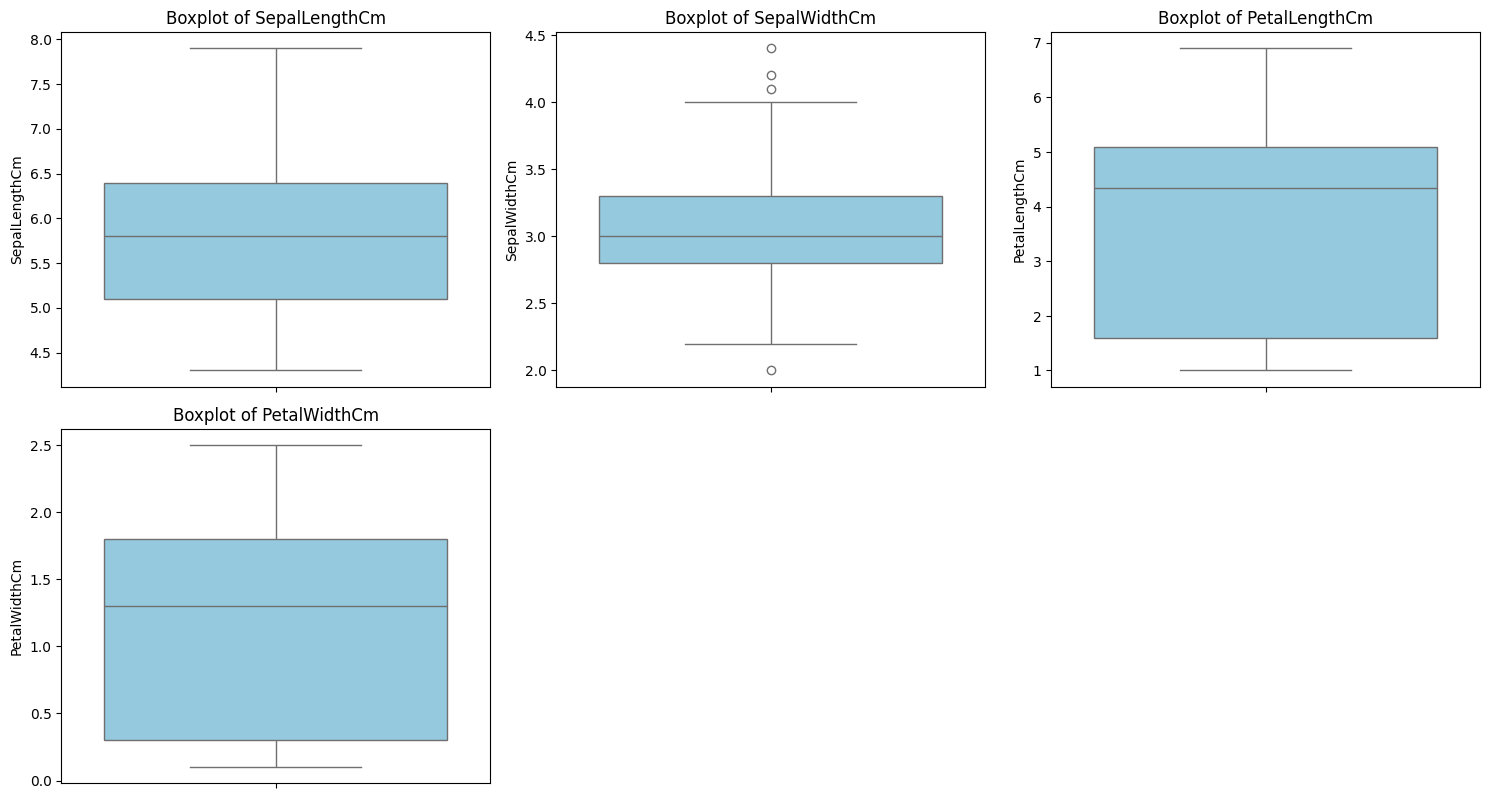

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
# -------------------------------
# Automatically select all numeric columns
# -------------------------------
numeric_cols = df.select_dtypes(include='number').columns
# -------------------------------
# Boxplot visualization for outlier detection
# -------------------------------
plt.figure(figsize=(15, 12)) # Adjusted figure size for more plots

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)  # Changed to 3 rows, 3 columns to fit all 9 numeric columns
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [79]:
import pandas as pd

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)



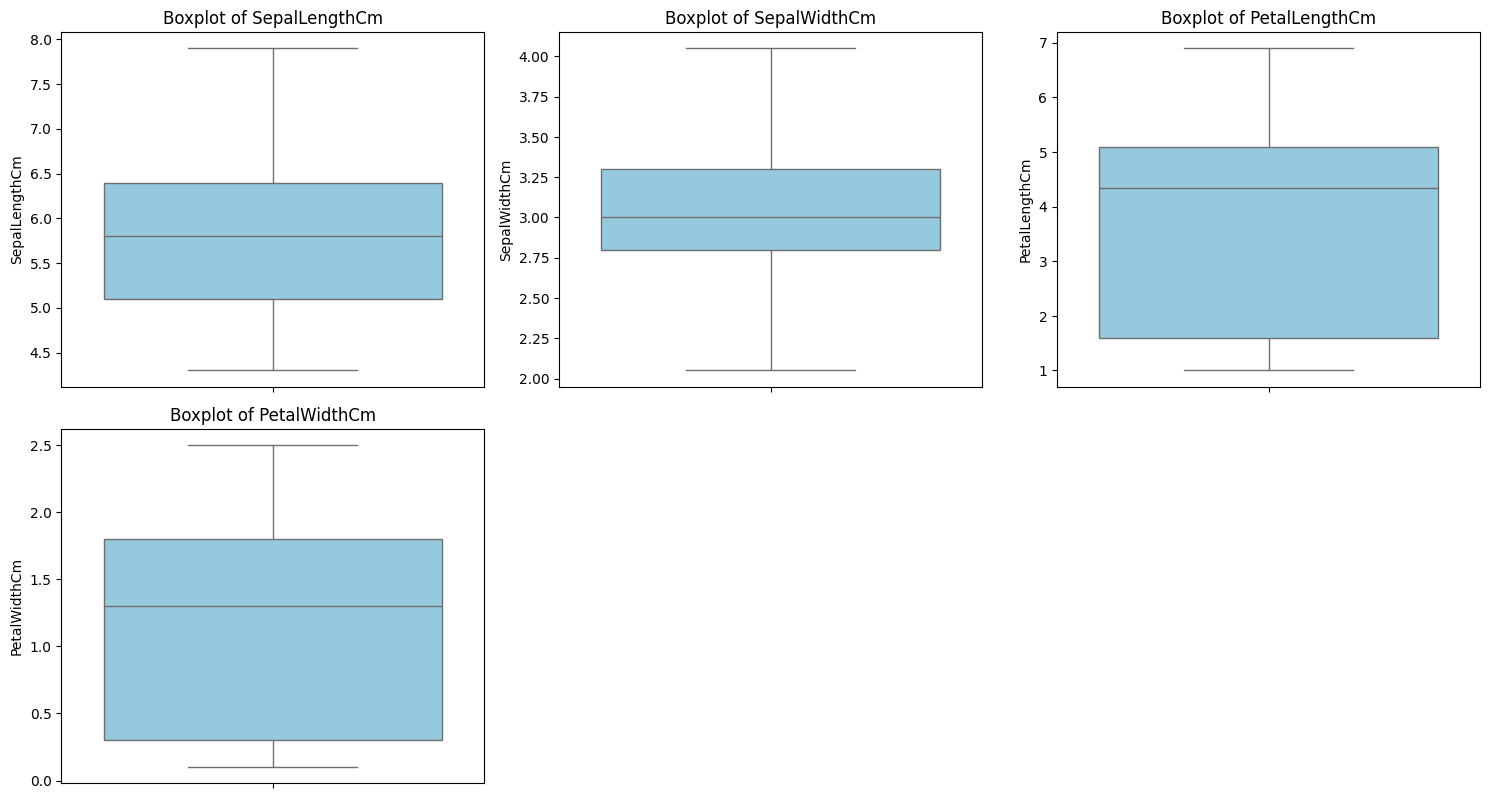

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
# -------------------------------
# Automatically select all numeric columns
# -------------------------------
numeric_cols = df.select_dtypes(include='number').columns
# -------------------------------
# Boxplot visualization for outlier detection
# -------------------------------
plt.figure(figsize=(15, 12)) # Adjusted figure size for more plots

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)  # Changed to 3 rows, 3 columns to fit all 9 numeric columns
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

Number of samples in class Iris-setosa: 50
Number of samples in class Iris-versicolor: 50
Number of samples in class Iris-virginica: 50


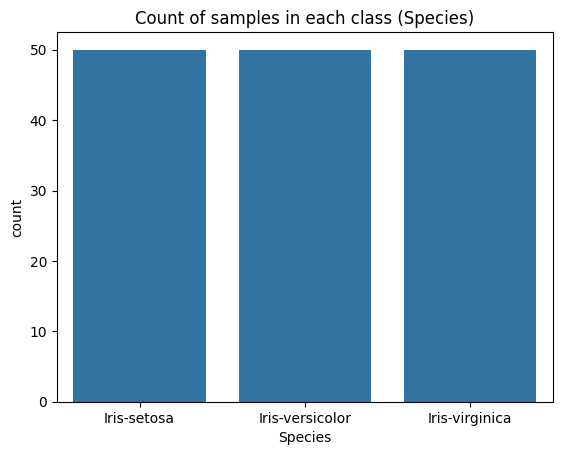

In [81]:
# Replace 'TargetColumn' with your actual target column name
target_col = 'Species'

# Count each class
class_counts = df[target_col].value_counts()
for cls, count in class_counts.items():
    print(f"Number of samples in class {cls}: {count}")

# Optional: visualize with countplot
sns.countplot(x=target_col, data=df)
plt.title(f'Count of samples in each class ({target_col})')
plt.show()


In [82]:
X = df.drop('Species', axis=1)
y = df['Species']

In [89]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

y = pd.Series(le.fit_transform(df['Species']), name='Species')

X = df.drop('Species', axis=1)

y.head(69)


,Species
0,0
1,0
2,0
3,0
4,0
...,...
64,1
65,1
66,1
67,1


In [84]:
from sklearn.preprocessing import StandardScaler
# Automatically select numeric columns
numeric_cols = X.select_dtypes(include='number').columns

# Scale all numeric features before splitting
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Numeric features have been scaled BEFORE train/test split.")
X

Numeric features have been scaled BEFORE train/test split.


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.065722,-1.341272,-1.312977
1,-1.143017,-0.120170,-1.341272,-1.312977
2,-1.385353,0.354187,-1.398138,-1.312977
3,-1.506521,0.117008,-1.284407,-1.312977
4,-1.021849,1.302901,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.120170,0.819624,1.447956
146,0.553333,-1.306063,0.705893,0.922064
147,0.795669,-0.120170,0.819624,1.053537
148,0.432165,0.828544,0.933356,1.447956


In [85]:
from sklearn.model_selection import train_test_split
# Only for classification models (KNN, Naive Bayes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # reproducible split
    stratify=y           # maintain class balance
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 120 rows
Test set: 30 rows


K = 2 --> Training Accuracy: 0.9667, Test Accuracy: 0.9333
Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



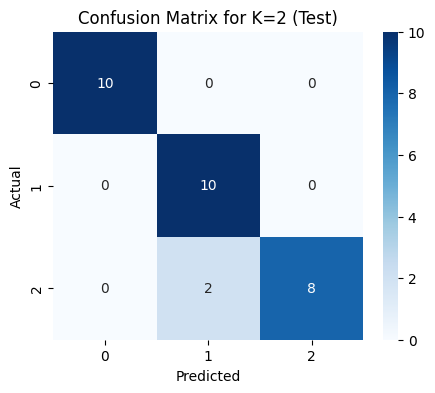

K = 10 --> Training Accuracy: 0.9583, Test Accuracy: 0.9667
Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



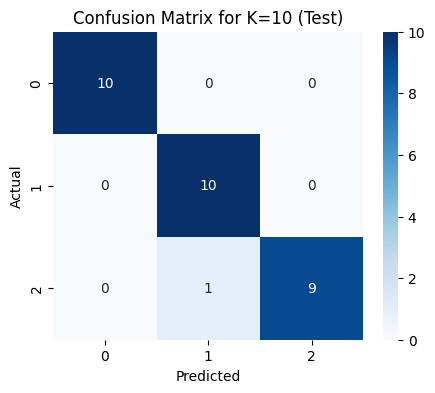

K = 20 --> Training Accuracy: 0.9500, Test Accuracy: 0.9333
Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



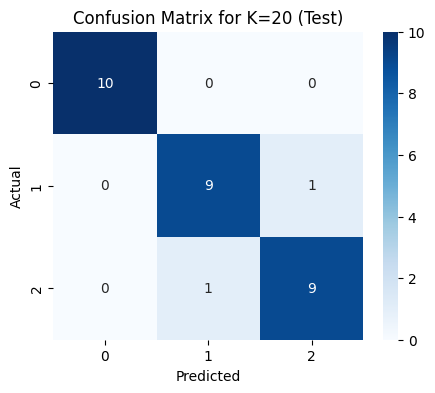

K = 30 --> Training Accuracy: 0.9083, Test Accuracy: 0.8667
Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.75      0.90      0.82        10
           2       0.88      0.70      0.78        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



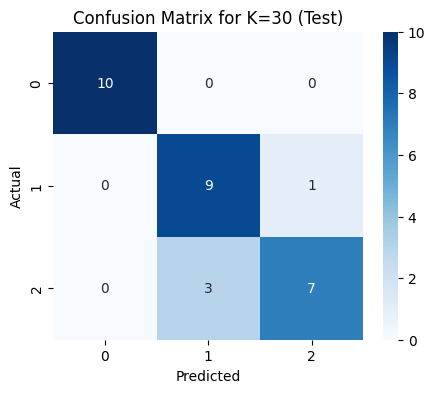

In [86]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# List of K values to try
k_values = [2,10,20,30]

for k in k_values:
    # Initialize KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train on training data
    knn.fit(X_train, y_train)

    # Predict on training and test data
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Evaluation metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"K = {k} --> Training Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix for test set
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for K={k} (Test)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Training Accuracy: 0.9583333333333334
Testing Accuracy: 0.9666666666666667

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



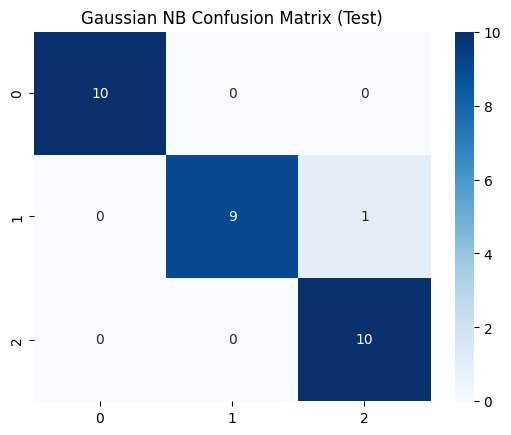

In [87]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# ---------------------------
# 3) Gaussian NB
# ---------------------------
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

# ---------------------------
# 4) Evaluation
# ---------------------------
# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

# Classification Report (Test)
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix (Test)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Gaussian NB Confusion Matrix (Test)")
plt.show()


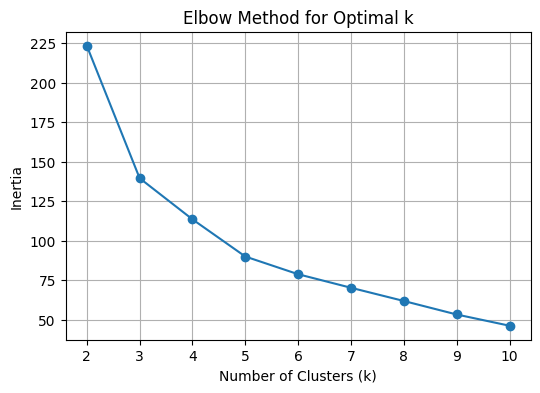

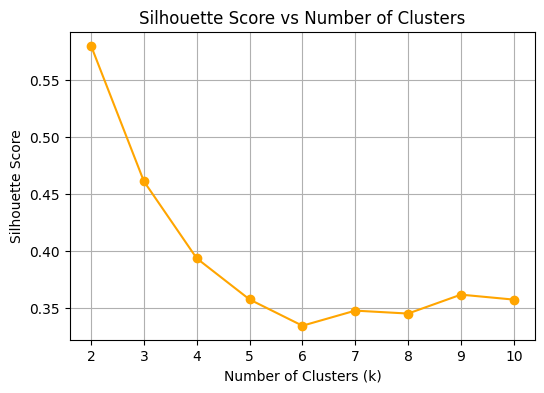

Best k based on Elbow: 3
Silhouette Score with k=3: 0.461


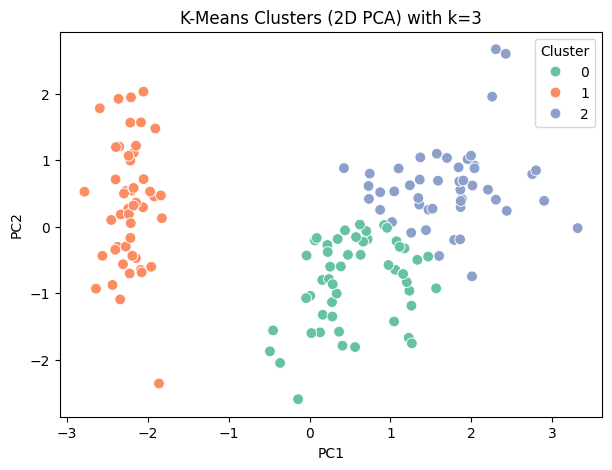

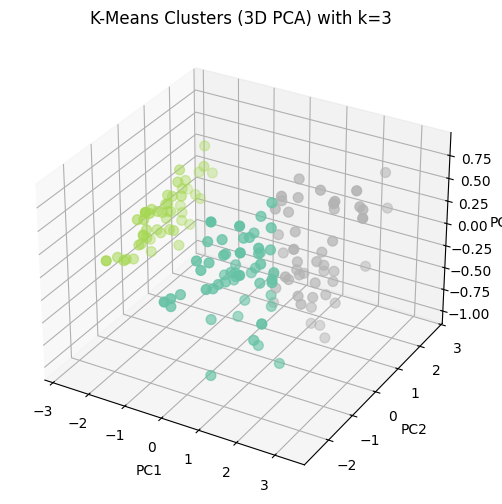

In [93]:
# ------------------------- #
#   1) Import Libraries
# ------------------------- #
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ------------------------- #
#   2) Preprocessing
# ------------------------- #
df_km = df.copy()

# Label encode categorical columns
for col in df_km.select_dtypes(include='object').columns:
    df_km[col] = LabelEncoder().fit_transform(df_km[col])

# Drop target if exists
if 'Species' in df_km.columns:
    df_km = df_km.drop('Species', axis=1)
if 'ID' in df_km.columns:
    df_km = df_km.drop('ID', axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_km)

# ------------------------- #
#   3) Elbow Method
# ------------------------- #
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Plot Silhouette Score vs k
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

# Choose best k based Elbow
k = 3
print(f"Best k based on Elbow: {k}")

# ------------------------- #
#   4) K-Means with Best k
# ------------------------- #
kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score with k={k}: {sil_score:.3f}")

# ------------------------- #
#   5) PCA for Visualization (2D)
# ------------------------- #
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1],
                hue=cluster_labels, palette='Set2', s=60)
plt.title(f"K-Means Clusters (2D PCA) with k={k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# ------------------------- #
#   6) PCA for Visualization (3D)
# ------------------------- #
pca3 = PCA(n_components=3)
X_pca_3d = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
           c=cluster_labels, cmap='Set2', s=50)
ax.set_title(f"K-Means Clusters (3D PCA) with k={k}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()
